In [1]:
# Importing required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Loading dataset

df = pd.read_csv("Mall_Customers.csv")

In [3]:
# Displaying first 5 records
df.head()

# Displaying last 5 records
df.tail()

# Displaying random sample records
df.sample(5)

# Checking dataset dimensions
print("Dataset Shape:", df.shape)

# Checking column names
print(df.columns)

# Checking dataset information
df.info()

# Statistical summary
df.describe()

Dataset Shape: (200, 5)
Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [4]:
# Checking missing values

df.isnull().sum()
# Checking duplicate records

df.duplicated().sum()

np.int64(0)

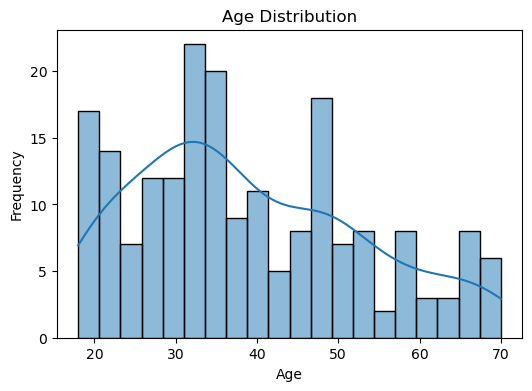

In [5]:
# Age Distribution

plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=20, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

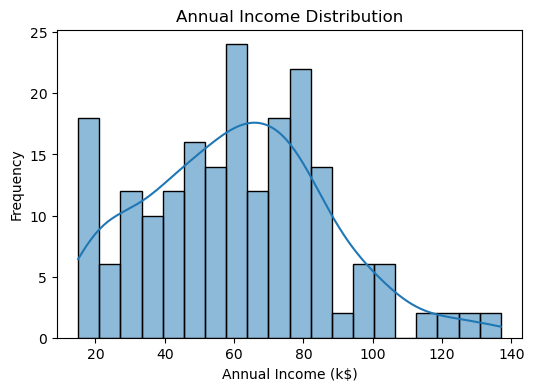

In [6]:
# Annual Income Distribution

plt.figure(figsize=(6,4))
sns.histplot(df['Annual Income (k$)'], bins=20, kde=True)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Frequency")

plt.show()

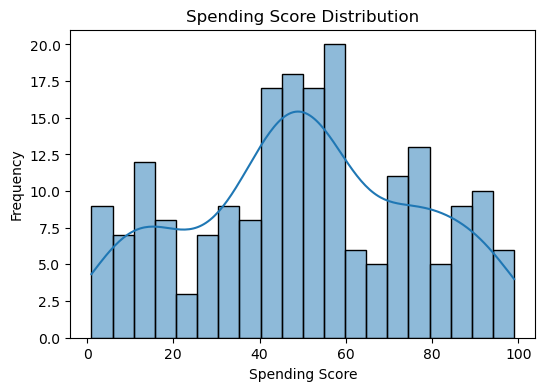

In [7]:
# Spending Score Distribution

plt.figure(figsize=(6,4))
sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True)

plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Frequency")

plt.show()

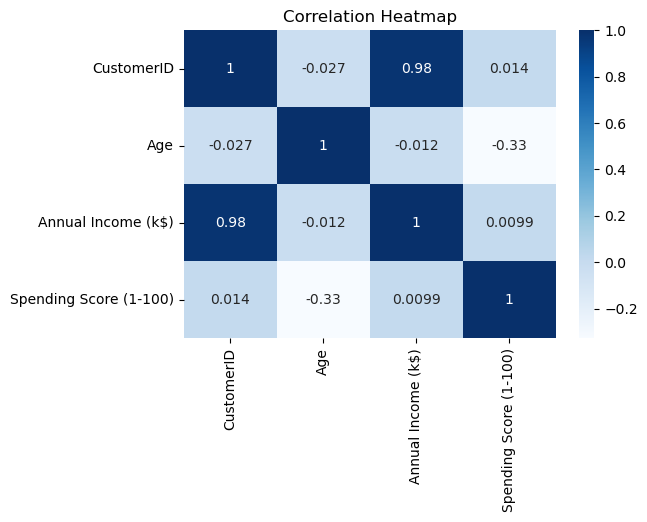

In [8]:
# Correlation Heatmap

plt.figure(figsize=(6,4))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='Blues'
)

plt.title("Correlation Heatmap")

plt.show()

In [9]:
# Encoding Gender column

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Genre'] = le.fit_transform(df['Genre'])

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


In [10]:
# Removing CustomerID column

df = df.drop('CustomerID', axis=1)

df.head()

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [11]:
# Scaling features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

print(X_scaled.shape)

(200, 4)


In [12]:
# Applying PCA

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(200, 2)


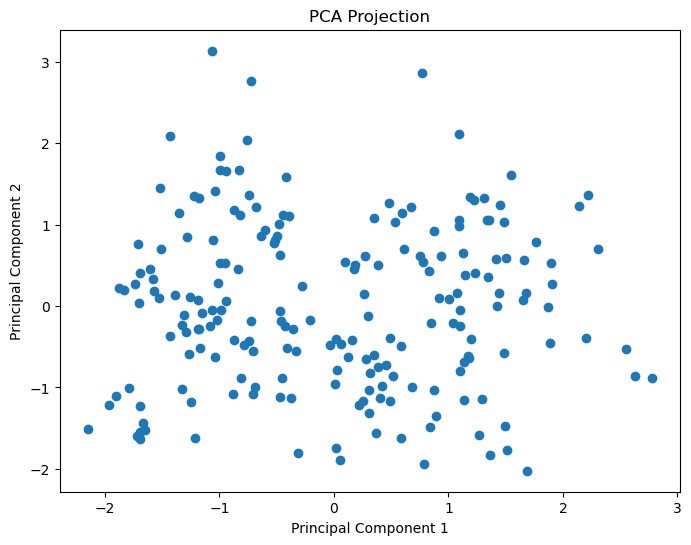

In [13]:
# Visualizing PCA Components

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1]
)

plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

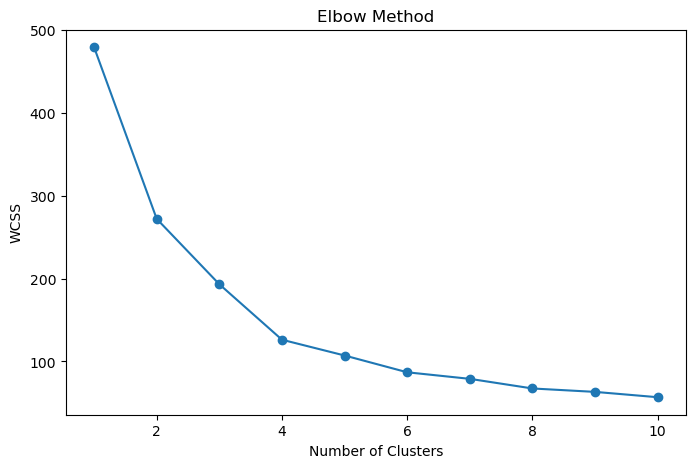

In [14]:
# Finding optimal number of clusters using Elbow Method

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(X_pca)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [15]:
# Calculating Silhouette Scores

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = kmeans.fit_predict(X_pca)

    score = silhouette_score(
        X_pca,
        labels
    )

    print(
        f"K = {k}, Silhouette Score = {score:.4f}"
    )

K = 2, Silhouette Score = 0.4014
K = 3, Silhouette Score = 0.3681
K = 4, Silhouette Score = 0.4123
K = 5, Silhouette Score = 0.4038
K = 6, Silhouette Score = 0.4032
K = 7, Silhouette Score = 0.3776
K = 8, Silhouette Score = 0.3584
K = 9, Silhouette Score = 0.3553
K = 10, Silhouette Score = 0.3285


In [16]:
# Applying KMeans Clustering

kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

clusters = kmeans.fit_predict(X_pca)

df['Cluster'] = clusters

df.head()

,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,19,15,39,4
1,1,21,15,81,4
2,0,20,16,6,1
3,0,23,16,77,2
4,0,31,17,40,2


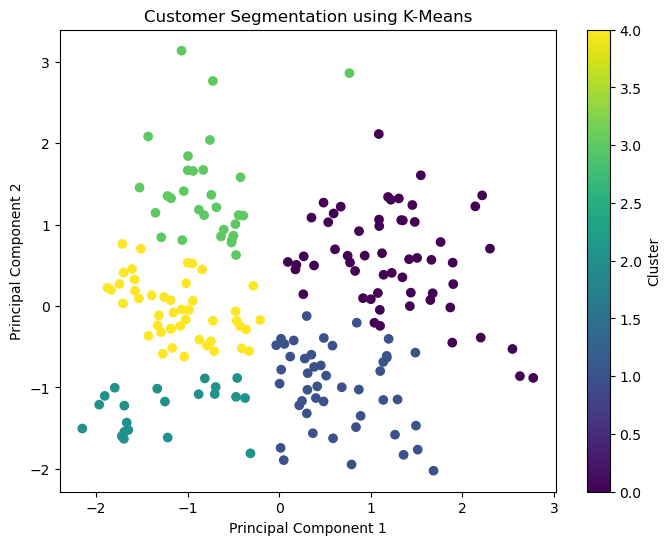

In [17]:
# Visualizing Customer Clusters

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df['Cluster'],
    cmap='viridis'
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")

plt.show()

In [18]:
# Number of customers in each cluster

df['Cluster'].value_counts().sort_index()

Cluster
0    57
1    46
2    21
3    30
4    46
Name: count, dtype: int64

In [19]:
# Saving clustered dataset

df.to_csv(
    "Customer_Segmentation_Clustered.csv",
    index=False
)

print("Clustered dataset saved successfully.")

Clustered dataset saved successfully.


In [20]:
df.groupby('Cluster').mean()

,Genre,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,0.789474,49.157895,70.210526,28.719298
1,0.065217,48.326087,46.652174,37.282609
2,0.000000,27.142857,30.809524,68.142857
3,0.866667,31.066667,85.700000,72.766667
4,0.304348,27.021739,59.695652,66.826087


In [21]:
df.head()


,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,19,15,39,4
1,1,21,15,81,4
2,0,20,16,6,1
3,0,23,16,77,2
4,0,31,17,40,2
